In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from skimage.feature import blob_log
from skimage.filters import gaussian
from skimage.restoration import denoise_tv_chambolle

from skimage.filters import sobel, threshold_otsu 
from skimage.morphology import remove_small_objects 

from scipy.ndimage import gaussian_laplace

from skimage.filters import threshold_multiotsu

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
PREPROCESSING_DIR = PROJECT_ROOT / "Image-Preprocessing"

sys.path.insert(
    0,
    str(PREPROCESSING_DIR),
)

import basic_data_preprocessing as bdp
import foreground_preprocessing as fp



mode: I;16B
shape: (2672, 4008)
dtype: >u2
min: 89
max: 271
unique values: 84


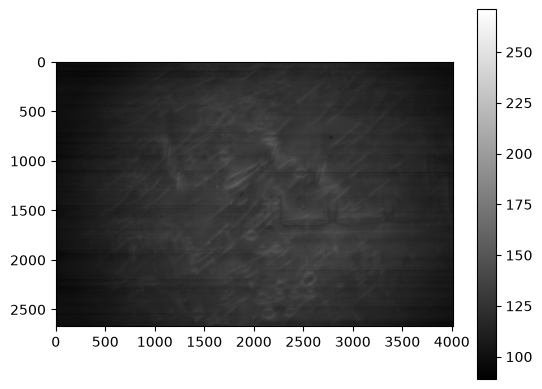

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image = Image.open("image.tif")
array = np.asarray(image)

print("mode:", image.mode)
print("shape:", array.shape)
print("dtype:", array.dtype)
print("min:", array.min())
print("max:", array.max())
print("unique values:", len(np.unique(array)))

plt.imshow(array, cmap="gray")
plt.colorbar()
plt.show()

np.save("image.npy", array)

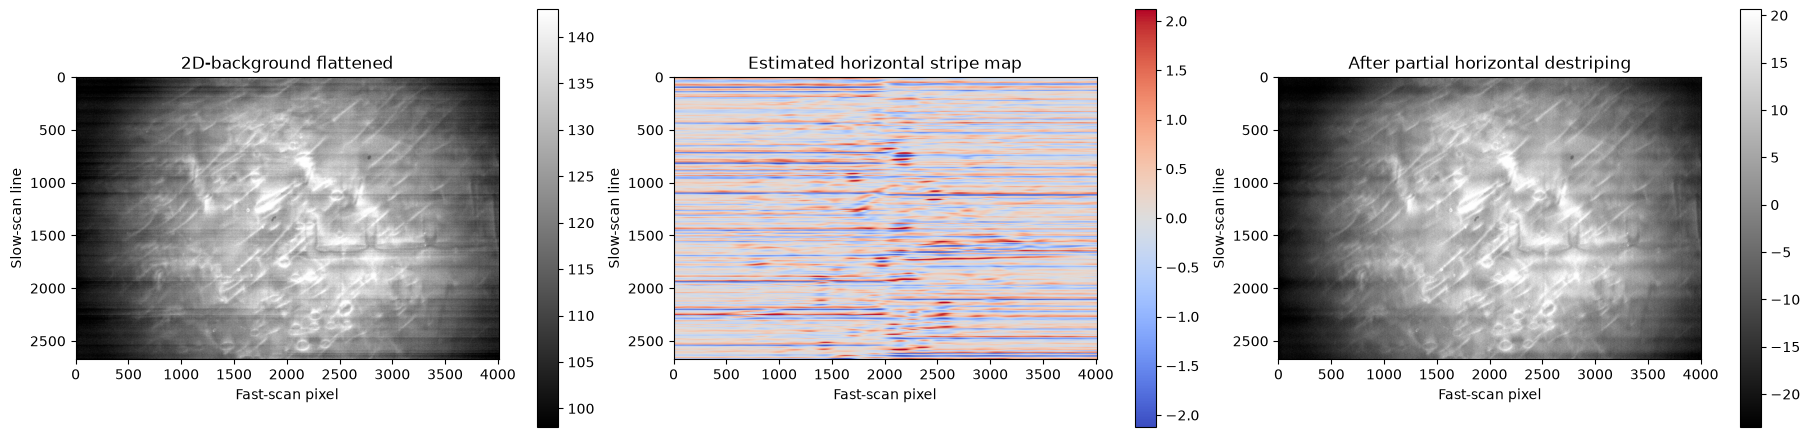

In [3]:
z_flat_2d = np.load("image.npy")

def remove_partial_horizontal_stripes(
    image,
    sigma_x=35,
    sigma_y_small=1.0,
    sigma_y_large=12.0,
    strength=0.8,
):
    """
    Remove partial horizontal stripe artefacts from an already flattened image.

    Idea:
    - smooth strongly along x so horizontally-elongated structures survive
    - compare a narrowly y-smoothed version with a broadly y-smoothed version
    - their difference estimates horizontal banding that changes rapidly in y
      but slowly in x

    Parameters
    ----------
    image : 2D array, Input AFM image, preferably after plane/background flattening.
    sigma_x : float, Smoothing along x (fast-scan direction). Larger values focus more on long horizontal structures.
    sigma_y_small : float, Small smoothing across rows.
    sigma_y_large : float, Large smoothing across rows. Must be larger than sigma_y_small.
    strength : float, Fraction of the estimated stripe map to subtract, Start with 0.5-0.8 rather than 1.0.
    """

    image = np.asarray(image, dtype=float)

    finite = np.isfinite(image)
    filled = image.copy()
    filled[~finite] = np.nanmedian(image[finite])

    # Slight pre-smoothing to reduce isolated dots dominating the estimate
    pre = gaussian_filter(filled, sigma=(0.6, 0.6), mode="reflect",)

    # Keep horizontally-elongated structures
    horiz_small_y = gaussian_filter(pre, sigma=(sigma_y_small, sigma_x), mode="reflect",)
    horiz_large_y = gaussian_filter(pre, sigma=(sigma_y_large, sigma_x), mode="reflect",)

    # Horizontal stripe estimate: structures smooth in x, narrow in y
    stripe_map = horiz_small_y - horiz_large_y
    corrected = filled - strength * stripe_map
    corrected[~finite] = np.nan
    stripe_map[~finite] = np.nan

    return corrected, stripe_map


z_destriped_2d, stripe_map_2d = remove_partial_horizontal_stripes(
    z_flat_2d,
    sigma_x=50,
    sigma_y_small=2.0,
    sigma_y_large=16.0,
    strength=1.0,
)

z_destriped_2d -= np.nanmedian(z_destriped_2d)


fig, axes = plt.subplots(1, 3, figsize=(18, 5),constrained_layout=True,)

# Input
vmin0, vmax0 = np.nanpercentile(z_flat_2d, [1, 99])
im0 = axes[0].imshow(z_flat_2d, cmap="gray", vmin=vmin0, vmax=vmax0,)
axes[0].set_title("2D-background flattened")
axes[0].set_xlabel("Fast-scan pixel")
axes[0].set_ylabel("Slow-scan line")
fig.colorbar(im0, ax=axes[0], shrink=0.85)

# Stripe map
limit = np.nanpercentile(np.abs(stripe_map_2d), 99)
im1 = axes[1].imshow(stripe_map_2d, cmap="coolwarm", vmin=-limit, vmax=limit,)
axes[1].set_title("Estimated horizontal stripe map")
axes[1].set_xlabel("Fast-scan pixel")
axes[1].set_ylabel("Slow-scan line")
fig.colorbar(im1, ax=axes[1], shrink=0.85)

# Corrected
vmin2, vmax2 = np.nanpercentile(z_destriped_2d, [1, 99])
im2 = axes[2].imshow(z_destriped_2d, cmap="gray", vmin=vmin2, vmax=vmax2,)
axes[2].set_title("After partial horizontal destriping")
axes[2].set_xlabel("Fast-scan pixel")
axes[2].set_ylabel("Slow-scan line")
fig.colorbar(im2, ax=axes[2], shrink=0.85)

plt.show()

In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "Image-Preprocessing").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT: raise FileNotFoundError("Could not find project root containing Image-Preprocessing")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "Image-Preprocessing"))

import basic_data_preprocessing as bdp
import foreground_preprocessing as fp
import detection_algorithms as da
import detection_errors as de

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis


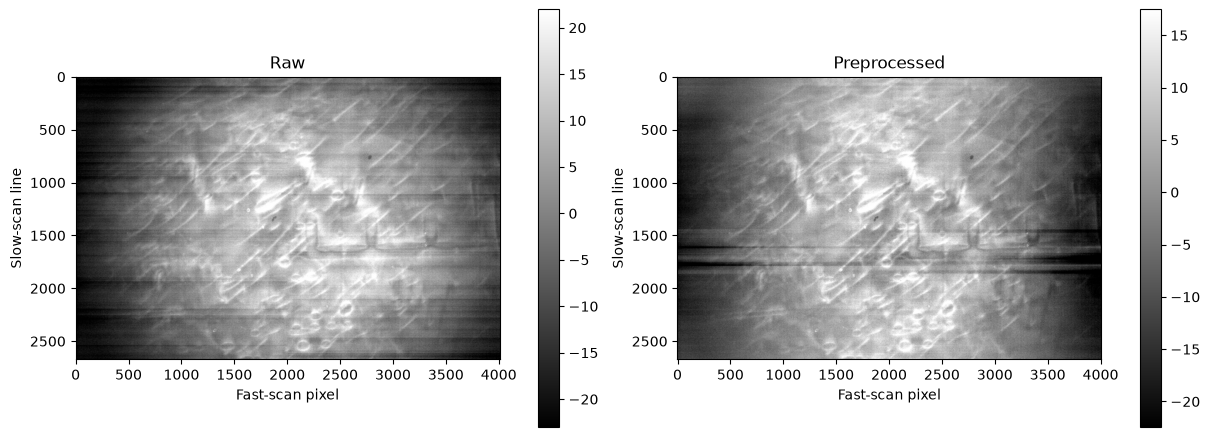

In [5]:
import numpy as np
import matplotlib.pyplot as plt

raw = np.asarray(image, dtype=float)

processed, stages = bdp.preprocess_afm(
    raw,
    remove_plane=True,
    line_flatten=True,
    align_rows=True,
    remove_2d_background=False,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    constrained_layout=True,
)

# -------------------------
# RAW IMAGE
# -------------------------

raw_display = raw - np.nanmedian(raw)

raw_vmin, raw_vmax = np.nanpercentile(
    raw_display,
    [1, 99],
)

raw_plot = axes[0].imshow(
    raw_display,
    cmap="gray",
    vmin=raw_vmin,
    vmax=raw_vmax,
    origin="upper",
)

axes[0].set_title("Raw")
axes[0].set_xlabel("Fast-scan pixel")
axes[0].set_ylabel("Slow-scan line")

fig.colorbar(
    raw_plot,
    ax=axes[0],
    shrink=0.85,
)


# -------------------------
# PREPROCESSED IMAGE
# -------------------------

processed_vmin, processed_vmax = np.nanpercentile(
    processed,
    [1, 99],
)

processed_plot = axes[1].imshow(
    processed,
    cmap="gray",
    vmin=processed_vmin,
    vmax=processed_vmax,
    origin="upper",
)

axes[1].set_title("Preprocessed")
axes[1].set_xlabel("Fast-scan pixel")
axes[1].set_ylabel("Slow-scan line")

fig.colorbar(
    processed_plot,
    ax=axes[1],
    shrink=0.85,
)

plt.show()

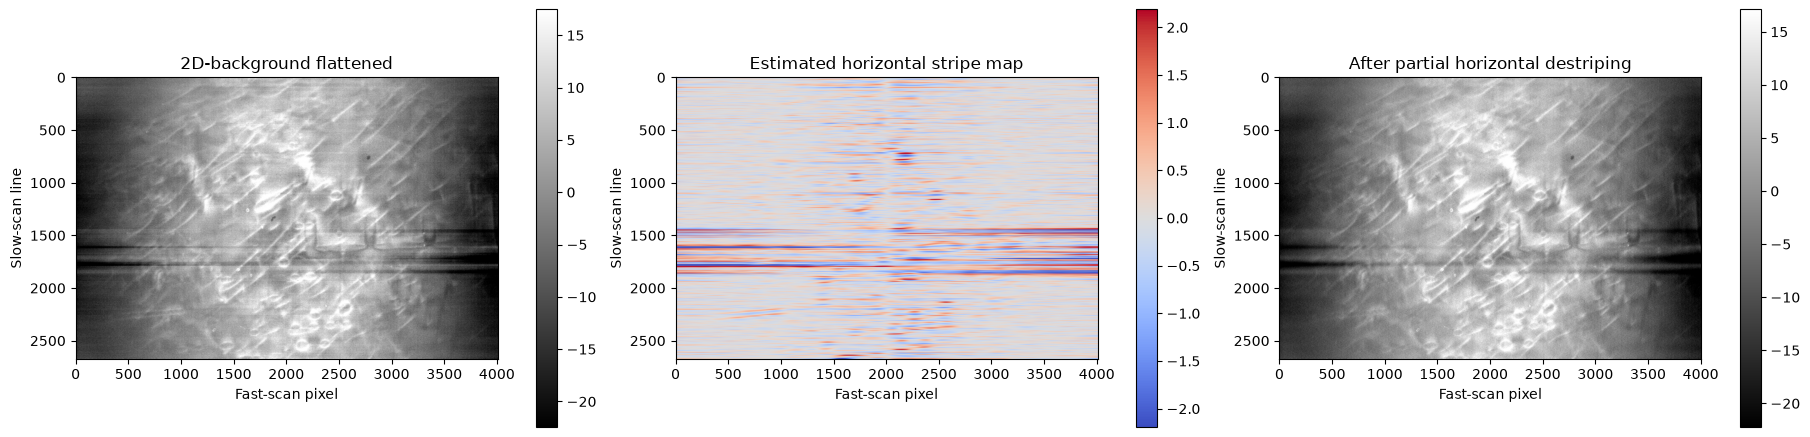

In [7]:
z_flat_2d = processed 

def remove_partial_horizontal_stripes(
    image,
    sigma_x=35,
    sigma_y_small=1.0,
    sigma_y_large=12.0,
    strength=0.8,
):
    """
    Remove partial horizontal stripe artefacts from an already flattened image.

    Idea:
    - smooth strongly along x so horizontally-elongated structures survive
    - compare a narrowly y-smoothed version with a broadly y-smoothed version
    - their difference estimates horizontal banding that changes rapidly in y
      but slowly in x

    Parameters
    ----------
    image : 2D array, Input AFM image, preferably after plane/background flattening.
    sigma_x : float, Smoothing along x (fast-scan direction). Larger values focus more on long horizontal structures.
    sigma_y_small : float, Small smoothing across rows.
    sigma_y_large : float, Large smoothing across rows. Must be larger than sigma_y_small.
    strength : float, Fraction of the estimated stripe map to subtract, Start with 0.5-0.8 rather than 1.0.
    """

    image = np.asarray(image, dtype=float)

    finite = np.isfinite(image)
    filled = image.copy()
    filled[~finite] = np.nanmedian(image[finite])

    # Slight pre-smoothing to reduce isolated dots dominating the estimate
    pre = gaussian_filter(filled, sigma=(0.6, 0.6), mode="reflect",)

    # Keep horizontally-elongated structures
    horiz_small_y = gaussian_filter(pre, sigma=(sigma_y_small, sigma_x), mode="reflect",)
    horiz_large_y = gaussian_filter(pre, sigma=(sigma_y_large, sigma_x), mode="reflect",)

    # Horizontal stripe estimate: structures smooth in x, narrow in y
    stripe_map = horiz_small_y - horiz_large_y
    corrected = filled - strength * stripe_map
    corrected[~finite] = np.nan
    stripe_map[~finite] = np.nan

    return corrected, stripe_map


z_destriped_2d, stripe_map_2d = remove_partial_horizontal_stripes(
    z_flat_2d,
    sigma_x=55,
    sigma_y_small=0.5,
    sigma_y_large=12.0,
    strength=1.0,
)

z_destriped_2d -= np.nanmedian(z_destriped_2d)


fig, axes = plt.subplots(1, 3, figsize=(18, 5),constrained_layout=True,)

# Input
vmin0, vmax0 = np.nanpercentile(z_flat_2d, [1, 99])
im0 = axes[0].imshow(z_flat_2d, cmap="gray", vmin=vmin0, vmax=vmax0,)
axes[0].set_title("2D-background flattened")
axes[0].set_xlabel("Fast-scan pixel")
axes[0].set_ylabel("Slow-scan line")
fig.colorbar(im0, ax=axes[0], shrink=0.85)

# Stripe map
limit = np.nanpercentile(np.abs(stripe_map_2d), 99)
im1 = axes[1].imshow(stripe_map_2d, cmap="coolwarm", vmin=-limit, vmax=limit,)
axes[1].set_title("Estimated horizontal stripe map")
axes[1].set_xlabel("Fast-scan pixel")
axes[1].set_ylabel("Slow-scan line")
fig.colorbar(im1, ax=axes[1], shrink=0.85)

# Corrected
vmin2, vmax2 = np.nanpercentile(z_destriped_2d, [1, 99])
im2 = axes[2].imshow(z_destriped_2d, cmap="gray", vmin=vmin2, vmax=vmax2,)
axes[2].set_title("After partial horizontal destriping")
axes[2].set_xlabel("Fast-scan pixel")
axes[2].set_ylabel("Slow-scan line")
fig.colorbar(im2, ax=axes[2], shrink=0.85)

plt.show()

In [7]:
#image = bdp.fft_bandpass_filter(image, low_sigma=5, high_sigma=40,)

#plt.imshow(image, cmap="gray")
#plt.colorbar()
#plt.show()

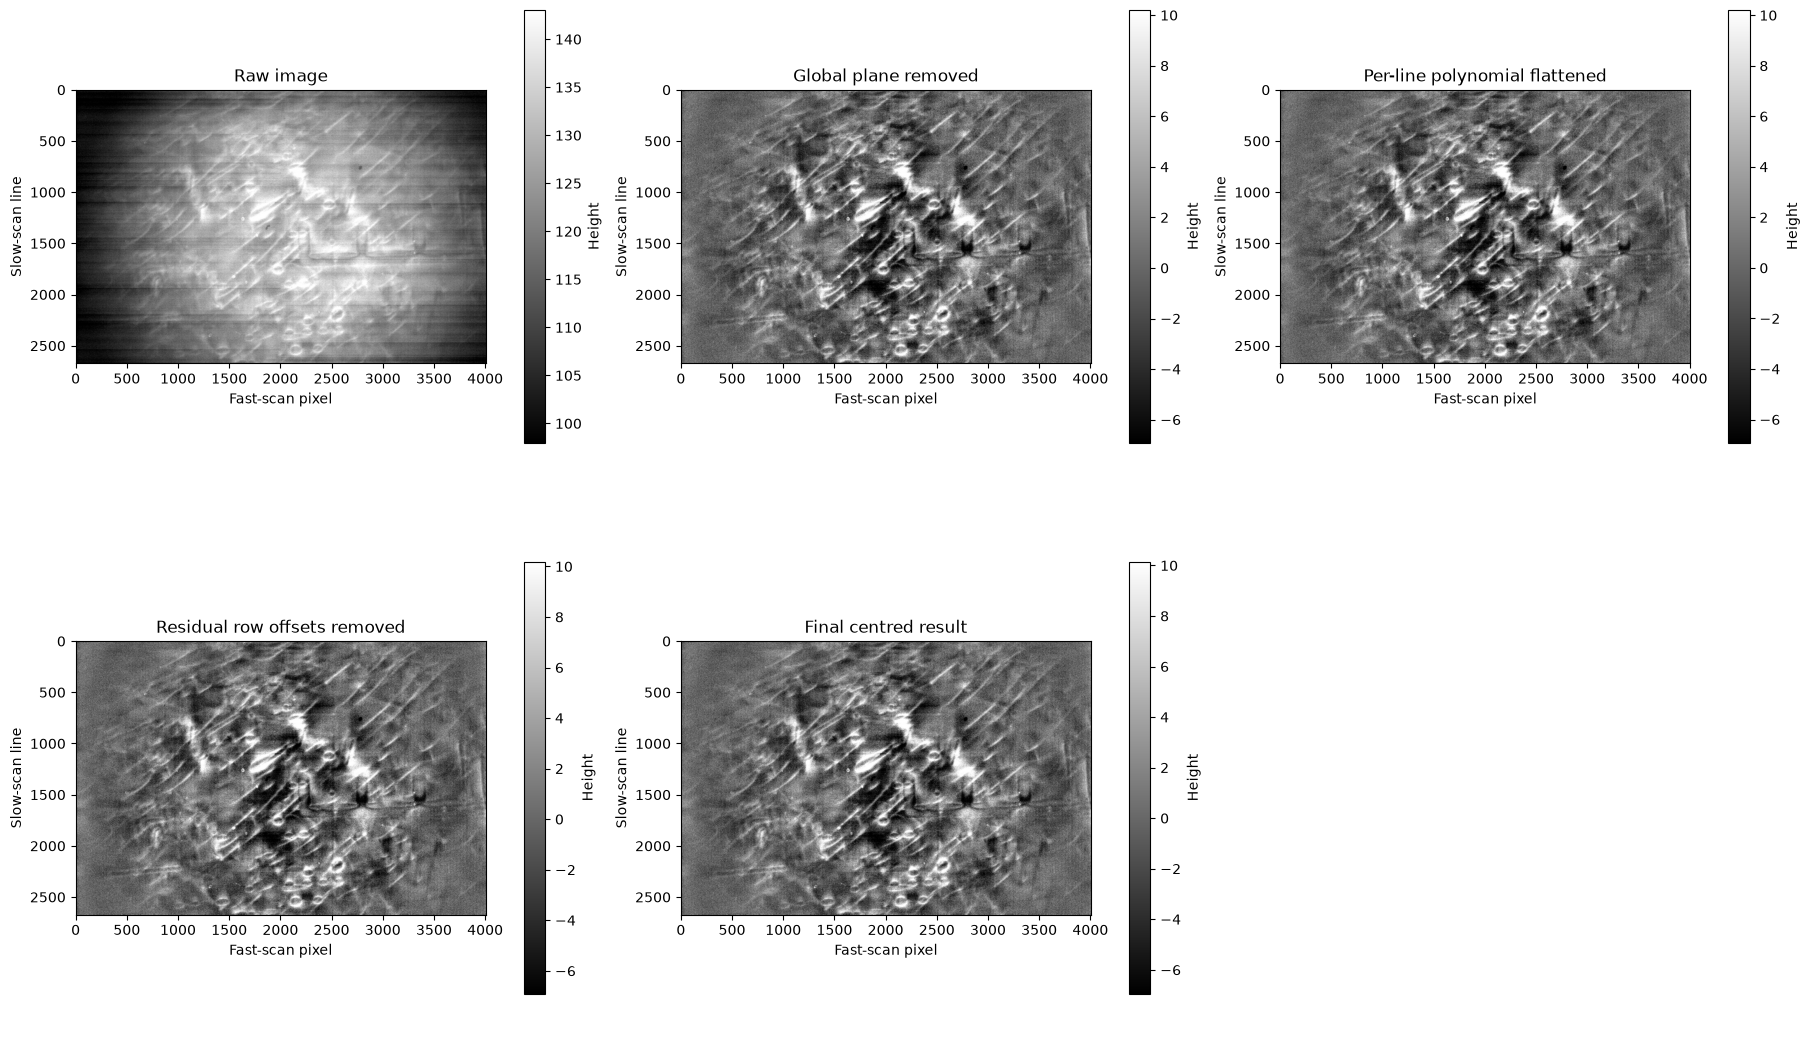

In [13]:
def mad(values):
    """Median absolute deviation, scaled like standard deviation."""
    values = np.asarray(values)
    median = np.nanmedian(values)
    return 1.4826 * np.nanmedian(np.abs(values - median))


def subtract_global_plane(z, n_iterations=5, sigma=3.0):
    """
    Fit and subtract z = ax + by + c using iterative outlier rejection.

    Large particles, holes, and contaminants are rejected from the plane fit.
    """
    z = np.asarray(z, dtype=float)

    ny, nx = z.shape
    yy, xx = np.indices(z.shape)

    finite = np.isfinite(z)
    mask = finite.copy()

    design = np.column_stack((xx[finite], yy[finite], np.ones(np.count_nonzero(finite)),))

    for _ in range(n_iterations):
        fit_mask = mask[finite]

        coefficients, *_ = np.linalg.lstsq(
            design[fit_mask],
            z[finite][fit_mask],
            rcond=None,
        )

        plane = (coefficients[0] * xx + coefficients[1] * yy + coefficients[2])

        residual = z - plane
        scale = mad(residual[mask])

        if not np.isfinite(scale) or scale == 0:
            break

        mask = finite & (np.abs(residual - np.nanmedian(residual[mask]))
                         < sigma * scale)

    plane = (coefficients[0] * xx + coefficients[1] * yy + coefficients[2])

    return z - plane, plane, mask


def robust_polynomial_line_flatten(
    z,
    degree=5,
    n_iterations=10,
    sigma=5,
    axis=1,
):
    """
    Flatten each scan line using iterative robust polynomial fitting.

    axis=1:
        Each row is treated as one scan line. Use for horizontal stripes.

    axis=0:
        Each column is treated as one scan line. Use for vertical stripes.

    degree=0 removes line offsets.
    degree=1 removes offset and line slope.
    degree=2 removes gentle line curvature.
    """
    z = np.asarray(z, dtype=float)

    if axis == 0:
        working = z.T.copy()
    elif axis == 1:
        working = z.copy()
    else:
        raise ValueError("axis must be 0 or 1")

    result = np.full_like(working, np.nan)
    backgrounds = np.full_like(working, np.nan)

    n_lines, n_points = working.shape
    x = np.linspace(-1.0, 1.0, n_points)

    for row_index in range(n_lines):
        line = working[row_index]
        finite = np.isfinite(line)

        if np.count_nonzero(finite) <= degree + 1:
            result[row_index] = line
            continue

        fit_mask = finite.copy()

        for _ in range(n_iterations):
            if np.count_nonzero(fit_mask) <= degree + 1:
                break

            coefficients = np.polyfit(x[fit_mask], line[fit_mask], degree,)

            background = np.polyval(coefficients, x)
            residual = line - background

            centre = np.nanmedian(residual[fit_mask])
            scale = mad(residual[fit_mask])

            if not np.isfinite(scale) or scale == 0:
                break

            fit_mask = finite & (np.abs(residual - centre) < sigma * scale)

        coefficients = np.polyfit(x[fit_mask], line[fit_mask], degree,)
        background = np.polyval(coefficients, x)

        result[row_index] = line - background
        backgrounds[row_index] = background

    if axis == 0:
        return result.T, backgrounds.T

    return result, backgrounds


def align_scanline_offsets(z, smoothing_window=15):
    """
    Remove residual row-to-row offsets.

    The offset of each row is estimated by its robust median and compared
    with a slowly varying median-filtered trend.
    """
    z = np.asarray(z, dtype=float)

    if smoothing_window % 2 == 0:
        smoothing_window += 1

    row_offsets = np.nanmedian(z, axis=1)

    valid = np.isfinite(row_offsets)
    filled = row_offsets.copy()

    if not np.all(valid):
        row_numbers = np.arange(len(row_offsets))
        filled[~valid] = np.interp(row_numbers[~valid], row_numbers[valid], row_offsets[valid],)

    smooth_offsets = median_filter(filled, size=smoothing_window, mode="nearest",)
    rapid_offset_error = filled - smooth_offsets
    corrected = z - rapid_offset_error[:, None]
    return corrected, rapid_offset_error



# Remove global image tilt first
z_plane_flat, fitted_plane, plane_mask = subtract_global_plane(
    image,
    n_iterations=6,
    sigma=2.5,
)

# Remove slope/background from every horizontal scan line
z_line_flat, line_background = robust_polynomial_line_flatten(
    z_plane_flat,
    degree=3,       # Start with 1; try 2 only if genuine curvature remains
    n_iterations=6,
    sigma=2.5,
    axis=1,         # Horizontal stripes -> fit each row
)

# Remove residual row-to-row jumps without removing slow sample variation
z_aligned, row_offset_error = align_scanline_offsets(
    z_line_flat,
    smoothing_window=21,
)

# Put the flattened result around zero
z_flat_aligned = z_aligned - np.nanmedian(z_aligned)
z_flat_aligned = z_aligned - np.nanmedian(z_aligned)


# Centre final result around zero
z_flat_aligned = z_aligned - np.nanmedian(z_aligned)

stages = [
    ("Raw image", raw),
    ("Global plane removed", z_plane_flat),
    ("Per-line polynomial flattened", z_line_flat),
    ("Residual row offsets removed", z_aligned),
    ("Final centred result", z_flat_aligned),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True,)

for ax, (title, image) in zip(axes.ravel(), stages):
    vmin, vmax = np.nanpercentile(image, [1, 99])

    im = ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax, origin="upper",)
    ax.set_title(title)
    ax.set_xlabel("Fast-scan pixel")
    ax.set_ylabel("Slow-scan line")
    fig.colorbar(im, ax=ax, label="Height", shrink=0.8,)

# Hide unused sixth panel
axes.ravel()[-1].axis("off")

plt.show()

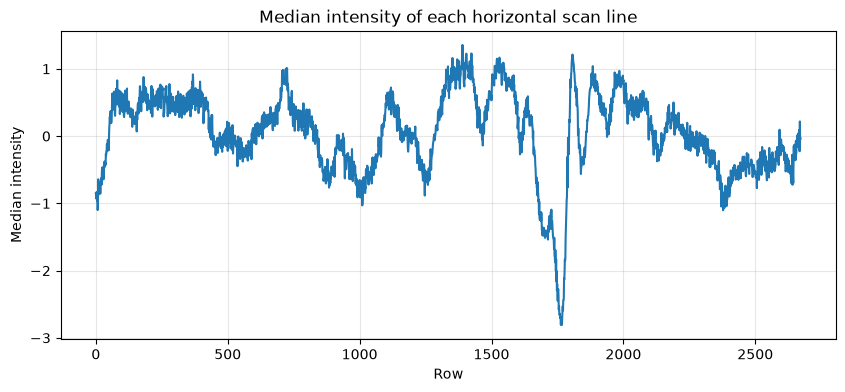

In [20]:
row_medians = np.nanmedian(z_destriped_2d, axis=1)

plt.figure(figsize=(10, 4))
plt.plot(row_medians)

plt.xlabel("Row")
plt.ylabel("Median intensity")
plt.title("Median intensity of each horizontal scan line")

plt.grid(alpha=0.3)
plt.show()

In [15]:
import numpy as np
from scipy.ndimage import gaussian_filter1d


def remove_horizontal_bands(
    image,
    smoothing_sigma=100,
):
    image = np.asarray(image, dtype=float)

    # Representative intensity of every row
    row_profile = np.nanmedian(
        image,
        axis=1,
    )

    # Very slowly varying underlying illumination/background
    smooth_profile = gaussian_filter1d(
        row_profile,
        sigma=smoothing_sigma,
        mode="nearest",
    )

    # Difference attributed to horizontal banding
    stripe_offsets = (
        row_profile - smooth_profile
    )

    corrected = (
        image - stripe_offsets[:, None]
    )

    return (
        corrected,
        row_profile,
        smooth_profile,
        stripe_offsets,
    )

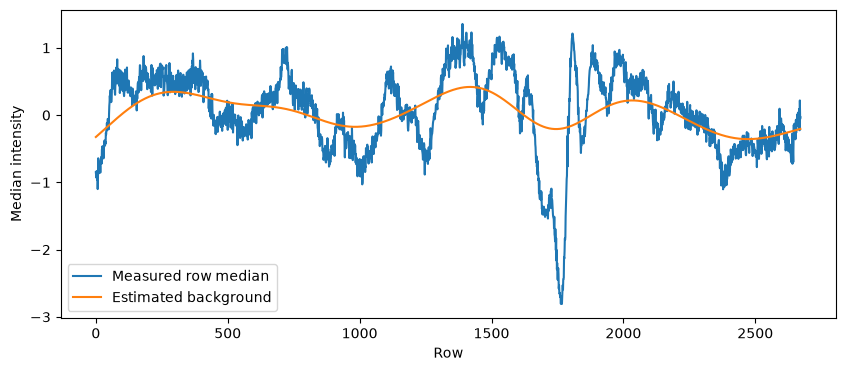

In [25]:
corrected, row_profile, smooth_profile, stripe_offsets = (
    remove_horizontal_bands(
        z_destriped_2d,
        smoothing_sigma=150,
    )
)

plt.figure(figsize=(10, 4))

plt.plot(
    row_profile,
    label="Measured row median",
)

plt.plot(
    smooth_profile,
    label="Estimated background",
)

plt.xlabel("Row")
plt.ylabel("Median intensity")
plt.legend()

plt.show()

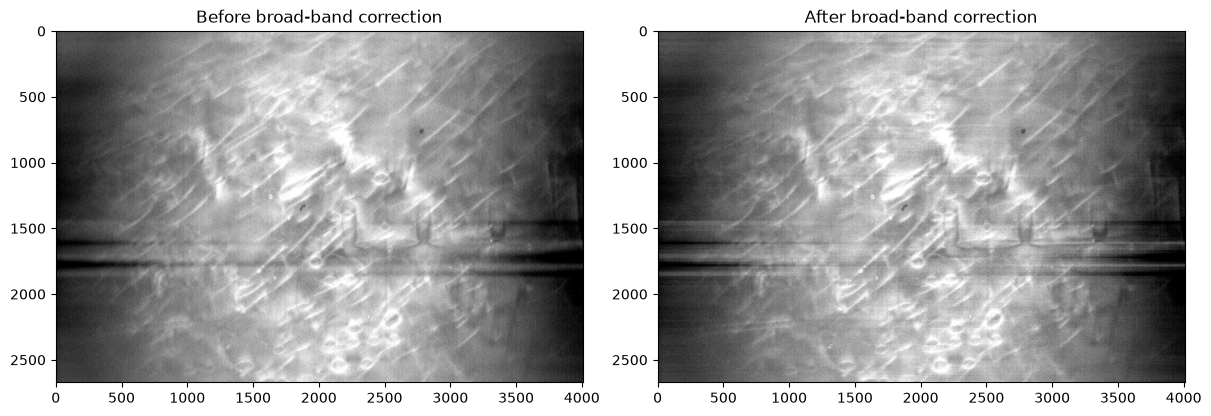

In [63]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    constrained_layout=True,
)

vmin, vmax = np.nanpercentile(
    z_destriped_2d,
    [1, 99],
)

axes[0].imshow(
    z_destriped_2d,
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title("Before broad-band correction")


vmin, vmax = np.nanpercentile(
    corrected,
    [1, 99],
)

axes[1].imshow(
    corrected,
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title("After broad-band correction")

plt.show()

In [43]:
import numpy as np
import matplotlib.pyplot as plt


def repair_horizontal_scanlines(
    image,
    threshold_sigma=4.0,
    max_gap=30,
):
    z = np.asarray(image, dtype=float).copy()

    # Difference between consecutive rows
    row_difference = np.nanmedian(
        np.abs(np.diff(z, axis=0)),
        axis=1,
    )

    centre = np.nanmedian(row_difference)

    mad = 1.4826 * np.nanmedian(
        np.abs(row_difference - centre)
    )

    threshold = centre + threshold_sigma * mad

    bad_boundaries = np.where(
        row_difference > threshold
    )[0]

    # Rows either side of a strong discontinuity
    bad_rows = np.unique(
        np.concatenate([
            bad_boundaries,
            bad_boundaries + 1,
        ])
    )

    bad_rows = bad_rows[
        bad_rows < z.shape[0]
    ]

    corrected = z.copy()

    # -------------------------------------------------
    # Interpolate corrupted rows from nearest good rows
    # -------------------------------------------------

    bad_mask = np.zeros(
        z.shape[0],
        dtype=bool,
    )

    bad_mask[bad_rows] = True

    good_rows = np.where(~bad_mask)[0]

    for x in range(z.shape[1]):

        corrected[:, x] = np.interp(
            np.arange(z.shape[0]),
            good_rows,
            z[good_rows, x],
        )

    return (
        corrected,
        row_difference,
        bad_rows,
        threshold,
    )

In [44]:
correctednew, row_difference, bad_rows, threshold = (
    repair_horizontal_scanlines(
        corrected,
        threshold_sigma=4.0,
    )
)

print("Detected bad rows:")
print(bad_rows)

Detected bad rows:
[1093 1094 1111 1112 1443 1444 1449 1450 1465 1466 1471 1472 1475 1476
 1477 1488 1489 1517 1518 1519 1598 1599 1600 1771 1772 1774 1775 1776
 1783 1784 1789 1790 1808 1809 1814 1815 1816 1823 1824 1849 1850 1860
 1861 1862 1863 1934 1935 2613 2614]


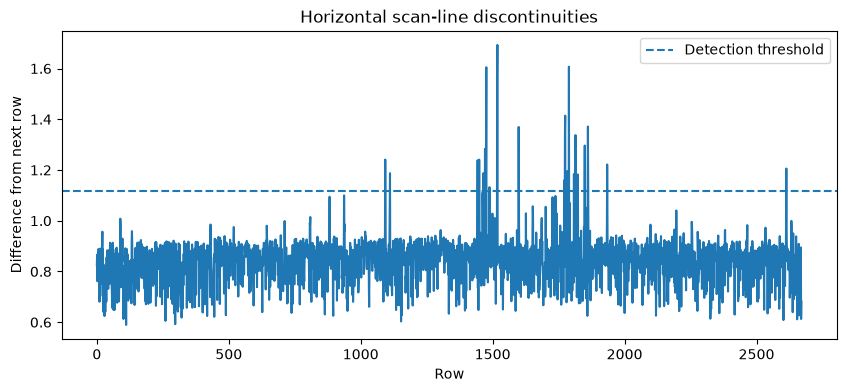

In [45]:
plt.figure(figsize=(10, 4))

plt.plot(row_difference)

plt.axhline(
    threshold,
    linestyle="--",
    label="Detection threshold",
)

plt.xlabel("Row")
plt.ylabel("Difference from next row")
plt.title("Horizontal scan-line discontinuities")

plt.legend()
plt.show()

In [55]:
import numpy as np
import matplotlib.pyplot as plt


def correct_horizontal_block(
    image,
    start_row=1400,
    end_row=1950,
    reference_width=100,
):
    z = np.asarray(image, dtype=float)
    corrected = z.copy()

    # Median value of every row
    row_medians = np.nanmedian(
        z,
        axis=1,
    )

    # Good rows immediately above/below the corrupted region
    upper_reference = np.nanmedian(
        row_medians[
            start_row - reference_width:start_row
        ]
    )

    lower_reference = np.nanmedian(
        row_medians[
            end_row:end_row + reference_width
        ]
    )

    # What we EXPECT the row median to do through the region:
    # smoothly transition from upper to lower reference.
    target_medians = np.linspace(
        upper_reference,
        lower_reference,
        end_row - start_row,
    )

    # Actual medians inside bad region
    actual_medians = row_medians[
        start_row:end_row
    ]

    # Offset of EVERY ROW, not just detected boundaries
    offsets = (
        actual_medians
        - target_medians
    )

    corrected[
        start_row:end_row
    ] -= offsets[:, None]

    return corrected, row_medians, target_medians, offsets

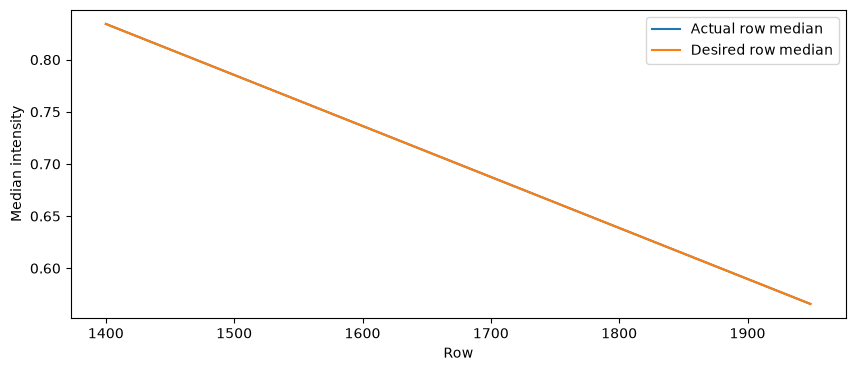

In [60]:
correctednew, row_medians, target_medians, offsets = (
    correct_horizontal_block(
        corrected,
        start_row=1400,
        end_row=1950,
        reference_width=100,
    )
)

plt.figure(figsize=(10, 4))

plt.plot(
    np.arange(1400, 1950),
    row_medians[1400:1950],
    label="Actual row median",
)

plt.plot(
    np.arange(1400, 1950),
    target_medians,
    label="Desired row median",
)

plt.xlabel("Row")
plt.ylabel("Median intensity")
plt.legend()

plt.show()

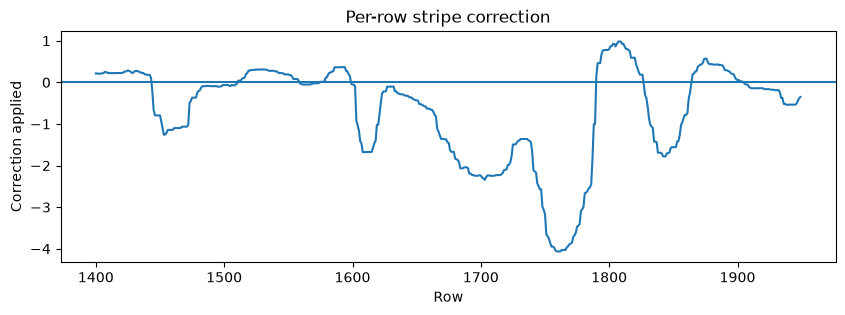

In [58]:
plt.figure(figsize=(10, 3))

plt.plot(
    np.arange(1400, 1950),
    offsets,
)

plt.axhline(0)

plt.xlabel("Row")
plt.ylabel("Correction applied")

plt.title("Per-row stripe correction")

plt.show()

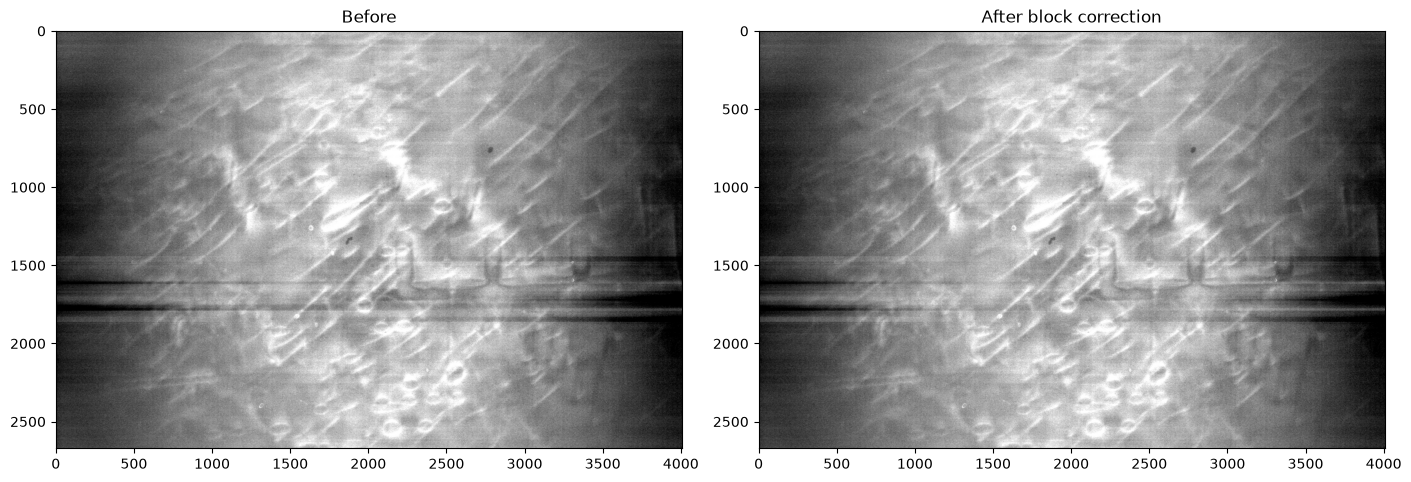

In [59]:
vmin, vmax = np.nanpercentile(
    processed,
    [1, 99],
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    constrained_layout=True,
)

axes[0].imshow(
    processed,
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_title("Before")


axes[1].imshow(
    corrected,
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_title("After block correction")

plt.show()